# Klassificering av ansiktsuttryck med CNN

I den här uppgiften bygger jag en deep learning-modell som ska kunna klassificera ansiktsuttryck från bilder. Datasetet som används är FER-2013.

Målet är att undersöka datan, förbereda bilderna, bygga och träna CNN-modeller, utvärdera resultatet och slutligen testa modellen på ny data.

Jag kommer att arbeta itterativt och jämföra flera modeller för att försöka uppnå bättre resultat och för att se hur olika val påverkar modellens prestanda.

In [1]:
# Grundläggande bibliotek
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models

# För utvärdering
from sklearn.metrics import classification_report, confusion_matrix

# För bildhantering
from PIL import Image

# För att göra resultatet mer reproducerbar
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Sökvägar till datasetet
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "raw" / "FER-2013"

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("Train folder exists:", TRAIN_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())

Train folder exists: True
Test folder exists: True


In [3]:
# Hämta klassnamn från träningsmappen
class_names = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

print("Klasser i datasetet:")
for class_name in class_names:
    print("-", class_name)

print("\nAntal klasser:", len(class_names))

Klasser i datasetet:
- angry
- disgust
- fear
- happy
- neutral
- sad
- surprise

Antal klasser: 7


In [4]:
# Räkna antal bilder i train och test för varje klass
data_summary = []

for class_name in class_names:
    train_count = len(list((TRAIN_DIR / class_name).glob("*")))
    test_count = len(list((TEST_DIR / class_name).glob("*")))
    
    data_summary.append({
        "class": class_name,
        "train_count": train_count,
        "test_count": test_count,
        "total_count": train_count + test_count
    })

summary_df = pd.DataFrame(data_summary)
summary_df

,class,train_count,test_count,total_count
0,angry,3995,958,4953
1,disgust,436,111,547
2,fear,4097,1024,5121
3,happy,7215,1774,8989
4,neutral,4965,1233,6198
5,sad,4830,1247,6077
6,surprise,3171,831,4002


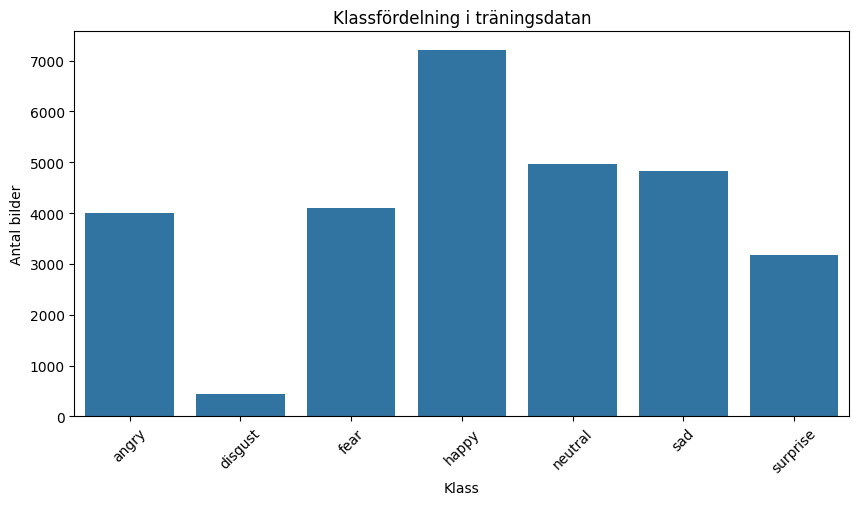

In [5]:
# Visualisera klassfördelningen i träningsdatan
plt.figure(figsize=(10, 5))
sns.barplot(data=summary_df, x="class", y="train_count")
plt.title("Klassfördelning i träningsdatan")
plt.xlabel("Klass")
plt.ylabel("Antal bilder")
plt.xticks(rotation=45)
plt.show()

## Förståelse av datan

Datasetet består av sju olika ansiktsuttryck: angry, disgust, fear, happy, neutral, sad och surprise. Bilderna är redan uppdelade i träningsdata och testdata, vilket gör det tydligt vilken data modellen ska lära sig från och vilken data som ska användas för slut utvärdering.

När jag undersökte klassfördelningen såg jag att vissa klasser har betydligt fler bilder än andra. Klassen `happy` har flest bilder, medan `disgust` har mycket färre bilder än övriga klasser. 

Detta kan påverka modellen eftersom den får färre exempel att lära sig från för just den klassen.

Det betyder att modellen kan bli bättre på att känna igen vanliga klasser och sämre på klasser med få exempel. 

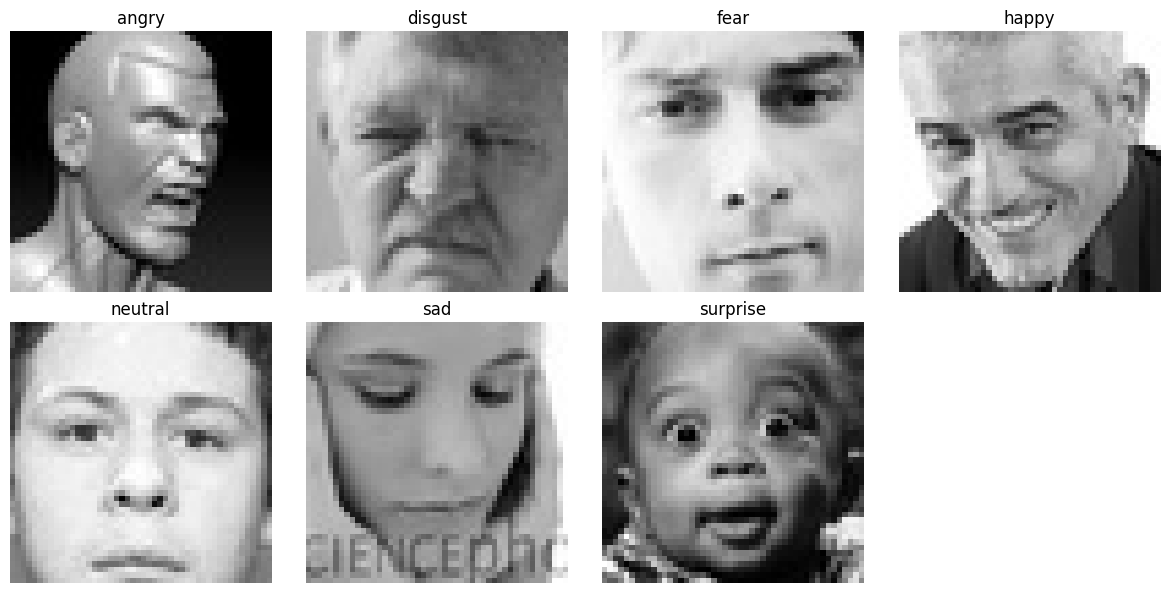

In [6]:
# Visa exempelbilder från varje klass
plt.figure(figsize=(12, 6))

for i, class_name in enumerate(class_names):
    image_paths = list((TRAIN_DIR / class_name).glob("*"))
    sample_image_path = random.choice(image_paths)
    
    image = Image.open(sample_image_path)
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Exempel på bilderna

Bilderna är små gråskalebilder med storleken 48x48 pixlar. Det gör uppgiften lite svårare eftersom ansiktena inte innehåller så mycket detaljinformation. Samtidigt passar den här typen av bilddata bra för en CNN-modell, eftersom convolutional layers kan lära sig mönster som kanter, former och delar av ansikten.

Eftersom bilderna är ganska små och ibland otydliga förväntar jag mig inte att modellen kommer bli perfekt, men den bör kunna lära sig vissa skillnader mellan uttrycken.

## Förberedelse av datan

Innan modellen kan tränas behöver bilderna läsas in på ett sätt som TensorFlow kan använda. Bilderna är redan uppdwlade i mappar för träning och test, där varje mapp motsvarar en klass.

Jag kommer att normalisera bilderna så att pixelvärdena går från 0–255 till 0–1. Det gör träningen stabilare eftersom neurala nätverk oftast fungerar bättre när input-värdena ligger i ett mindre intervall.

Eftersom datasetet är ganska stort börjar jag med en begränsad version av träningsdatan. Det gör det lättare att testa att koden och modellen fungerar innan jag eventuellt tränar på mer data.

In [7]:
# Inställningar för bilddata
IMG_HEIGHT = 48
IMG_WIDTH = 48
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 64
VALIDATION_SPLIT = 0.2

# Vi börjar med en mindre del av datan för snabbare testning
USE_SMALL_DATASET = True
MAX_IMAGES_PER_CLASS = 1000

In [8]:
# Läser in träningsdata med validation split
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

dataset_class_names = train_ds.class_names
print("Klassnamn från TensorFlow:", dataset_class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Klassnamn från TensorFlow: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [9]:
# Begränsa tränings- och valideringsdata i början för snabbare experiment
if USE_SMALL_DATASET:
    train_ds = train_ds.take(80)
    val_ds = val_ds.take(20)

print("Small dataset används:", USE_SMALL_DATASET)

Small dataset används: True


In [10]:
# Normalisering: pixelvärden från 0-255 till 0-1
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda images, labels: (normalization_layer(images), labels))
val_ds = val_ds.map(lambda images, labels: (normalization_layer(images), labels))
test_ds = test_ds.map(lambda images, labels: (normalization_layer(images), labels))

# Prefetch så TensorFlow kan ladda nästa batch medan modellen tränar
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
# Kontrollera att datan har rätt form
for images, labels in train_ds.take(1):
    print("Bildbatch shape:", images.shape)
    print("Labelbatch shape:", labels.shape)
    print("Min pixelvärde:", tf.reduce_min(images).numpy())
    print("Max pixelvärde:", tf.reduce_max(images).numpy())

Bildbatch shape: (64, 48, 48, 1)
Labelbatch shape: (64, 7)
Min pixelvärde: 0.0
Max pixelvärde: 1.0


## Analys av datförberedelsen

Bilderna har nu lästs in som gråskalebilder med formen 48x48x1. Det sista värdet betyder att bilden har en färgkanal, eftersom den är i gråskala.

Jag normaliserade bilderna genom att skala pixelvärdena från 0–255 till 0–1. Det gör att modellen får mer hanterbara input-värden och kan träna mer stabilt.

Jag använder också en validation split från träningsdatan. Det betyder att modellen tränas på en del av träningsdatan och utvärderas på en annan del under träningen. På så sätt kan jag följa om modellen faktiskt generaliserar bättre eller bara lär sig träningsdatan utantill.

I början använder jag en mindre del av datasetet för att snabbt kunna testa att modellen fungerar. Det är ett praktiskt sätt att arbeta när datasetet är stort och träningen annars kan ta lång tid.